In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [ ]:
data = pd.read_csv(r"/content/income.csv")

data.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


Text(0, 0.5, 'Income')

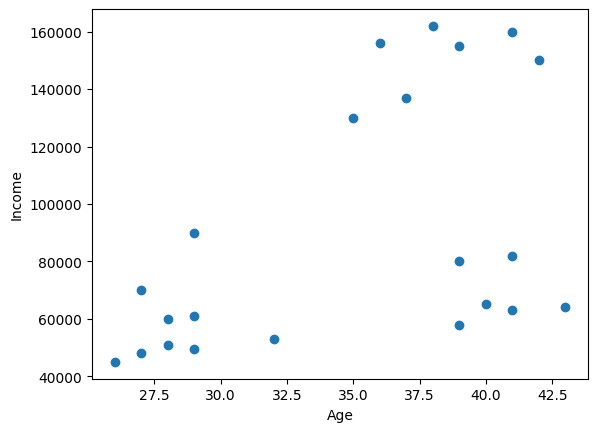

In [ ]:
plt.scatter(data["Age"],data["Income($)"])
plt.xlabel("Age")
plt.ylabel("Income")

In [ ]:
KM = KMeans(n_clusters=3)
y_predicted = KM.fit_predict(data[["Age","Income($)"]])
y_predicted

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [ ]:
data["Cluster"] = y_predicted

data.head()

,Name,Age,Income($),Cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [ ]:
KM.cluster_centers_

array([[3.29090909e+01, 5.61363636e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.40000000e+01, 8.05000000e+04]])

In [ ]:
C1 = data[data.Cluster == 0]
C2 = data[data.Cluster == 1]
C3 = data[data.Cluster == 2]

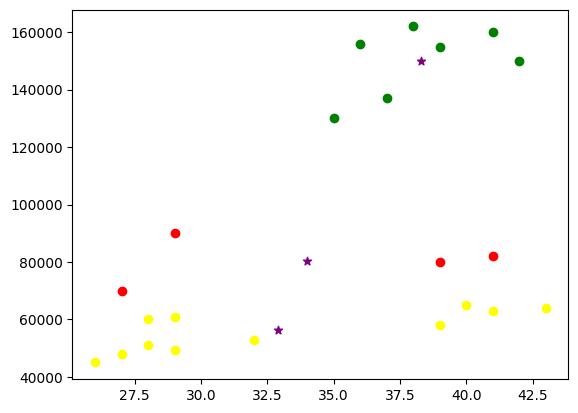

In [ ]:
plt.scatter(KM.cluster_centers_[:, 0], KM.cluster_centers_[:, 1], color="purple", marker='*', label="centroid")
plt.scatter(C1.Age,C1["Income($)"], color="yellow")
plt.scatter(C2.Age,C2["Income($)"], color="green")
plt.scatter(C3.Age,C3["Income($)"], color="red")

In [ ]:
MXS = MinMaxScaler()
MXS.fit(data[["Age","Income($)"]])
data["Age"] = MXS.fit_transform(data[["Age"]])
data["Income($)"] = MXS.fit_transform(data[["Income($)"]])

data.head()

,Name,Age,Income($),Cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


In [ ]:
KM1 = KMeans(n_clusters=3)
y_predicted1 = KM1.fit_predict(data[["Age","Income($)"]])

y_predicted1

array([2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [ ]:
data["Cluster2"] = y_predicted1

data.head()

,Name,Age,Income($),Cluster,Cluster2
0,Rob,0.058824,0.213675,2,2
1,Michael,0.176471,0.384615,2,2
2,Mohan,0.176471,0.136752,0,2
3,Ismail,0.117647,0.128205,0,2
4,Kory,0.941176,0.897436,1,1


In [ ]:
C1 = data[data.Cluster2 == 0]
C2 = data[data.Cluster2 == 1]
C3 = data[data.Cluster2 == 2]

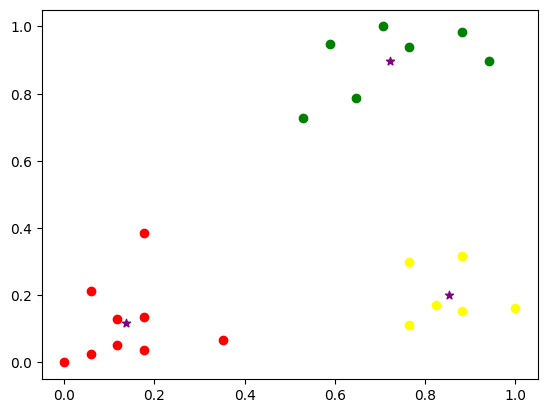

In [ ]:
plt.scatter(KM1.cluster_centers_[:, 0], KM1.cluster_centers_[:, 1], color="purple", marker='*', label="centroid")
plt.scatter(C1.Age,C1["Income($)"], color="yellow")
plt.scatter(C2.Age,C2["Income($)"], color="green")
plt.scatter(C3.Age,C3["Income($)"], color="red")

In [ ]:
SSE = []
K_range = range(1, 10)
for k in K_range:
  KM = KMeans(n_clusters=k)
  KM.fit(data[["Age","Income($)"]])
  SSE.append(KM.inertia_) # reture best K Cluster

In [ ]:
SSE

[5.434011511988179,
 2.091136388699078,
 0.4750783498553097,
 0.38815291664787444,
 0.33783731730034455,
 0.22037641690770673,
 0.1685851223602976,
 0.1424758252254333,
 0.1261838985292243]

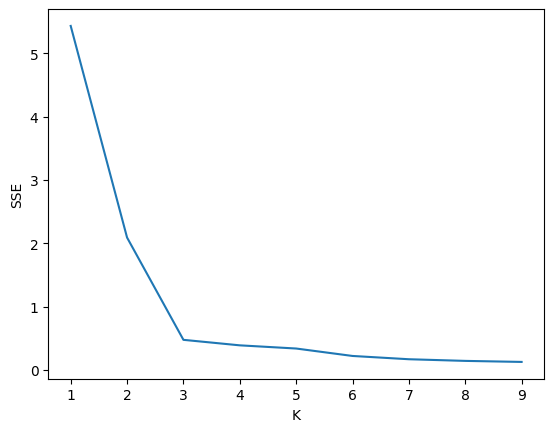

In [ ]:
plt.xlabel("K")
plt.ylabel("SSE")
plt.plot(K_range, SSE) # Best K = 3